In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

# Machine Learning Libraries
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.manifold import TSNE

# Visualization Settings
sns.set(style="whitegrid")
import warnings
warnings.filterwarnings("ignore")

# Load Data
print("Loading dataset...")
# Using a sample strategy if file is massive, otherwise load full
try:
    df = pd.read_excel('data/online_retail_II.xlsx')
except FileNotFoundError:
    print("Error: File not found. Please ensure 'online_retail_II.xlsx' is in the data folder.")
    # Create dummy data for demonstration if file missing
    data = {'Invoice': ['489434']*5, 'StockCode': ['85048']*5, 'Description': ['Item']*5,
            'Quantity': [12, 10, 2, 4, 1], 'InvoiceDate': [pd.Timestamp('2009-12-01')]*5,
            'Price': [6.95, 1.25, 2.10, 1.25, 1.65], 'Customer ID': [13085, 13085, 13085, 14000, 14000], 
            'Country': ['United Kingdom']*5}
    df = pd.DataFrame(data)

print(f"Data Loaded. Shape: {df.shape}")
df.head()

Loading dataset...
Data Loaded. Shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
## 1. Data Cleaning & Feature Engineering

# Remove Null Customer IDs (Crucial for segmentation)
df_clean = df.dropna(subset=['Customer ID'])

# Remove Returns (Negative Quantity) and Adjustments
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# Create TotalPrice column
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['Price']

# --- RFM CALCULATION ---
# Set reference date to 1 day after the last transaction
ref_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

# Group by Customer ID
rfm = df_clean.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (ref_date - x.max()).days, # Recency
    'Invoice': 'nunique',                                # Frequency (count unique invoices)
    'TotalPrice': 'sum'                                  # Monetary
})

# Rename columns
rfm.rename(columns={'InvoiceDate': 'Recency',
                    'Invoice': 'Frequency',
                    'TotalPrice': 'Monetary'}, inplace=True)

print(f"RFM Table Created. Unique Customers: {rfm.shape[0]}")
display(rfm.head())

# --- PREPROCESSING FOR K-MEANS ---
# K-Means assumes normal distribution and equal variance. 
# RFM data is usually right-skewed, so we Log Transform + Scale.

# 1. Log Transformation (handle skewness)
rfm_log = np.log1p(rfm)

# 2. Standardization (Scale to mean=0, std=1)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm.columns)

print("Data Preprocessing Complete.")

RFM Table Created. Unique Customers: 4312


,Recency,Frequency,Monetary
Customer ID,,,
12346.0,165,11,372.86
12347.0,3,2,1323.32
12348.0,74,1,222.16
12349.0,43,3,2671.14
12351.0,11,1,300.93


Data Preprocessing Complete.


Running K-Means for K=2 to 10...


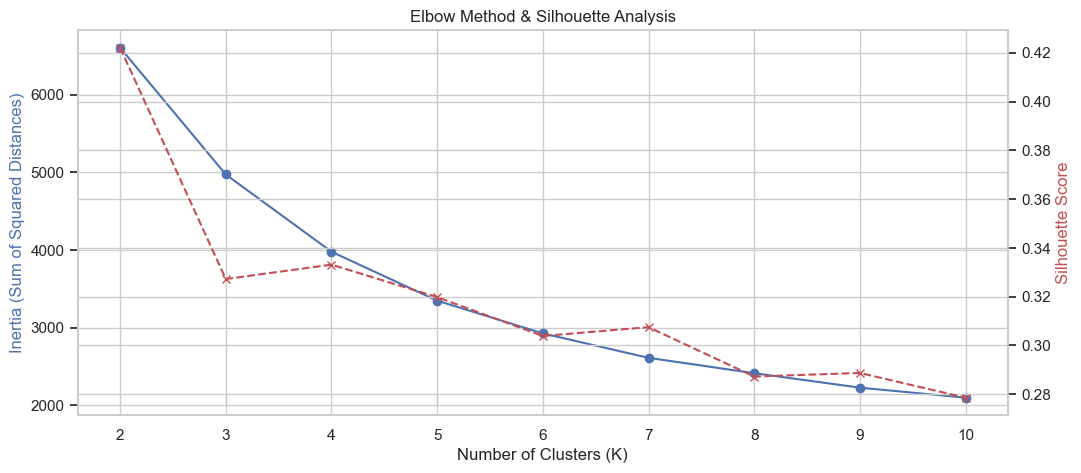

Interpretation: Look for the 'Elbow' where inertia starts flattening out.
Max Silhouette Score is at K=2


In [3]:
## 2. Modeling: Finding Optimal K (Hyperparameter Tuning)

inertia = []
silhouette_scores = []
k_range = range(2, 11)

print("Running K-Means for K=2 to 10...")

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    score = silhouette_score(rfm_scaled, kmeans.labels_)
    silhouette_scores.append(score)

# Plotting the Elbow Curve and Silhouette Scores
fig, ax1 = plt.subplots(figsize=(12, 5))

# Elbow Plot
ax1.plot(k_range, inertia, marker='o', color='b')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia (Sum of Squared Distances)', color='b')
ax1.set_title('Elbow Method & Silhouette Analysis')
ax1.grid(True)

# Silhouette Plot (Overlay)
ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, marker='x', color='r', linestyle='--')
ax2.set_ylabel('Silhouette Score', color='r')

plt.show()

print("Interpretation: Look for the 'Elbow' where inertia starts flattening out.")
print(f"Max Silhouette Score is at K={k_range[np.argmax(silhouette_scores)]}")

Cluster Summary (Means):


,Recency,Frequency,Monetary,Count
Cluster,,,,
3,13.99,13.68,7498.64,767
2,83.19,4.12,1775.01,1188
0,22.25,2.12,576.95,945
1,185.94,1.29,302.14,1412


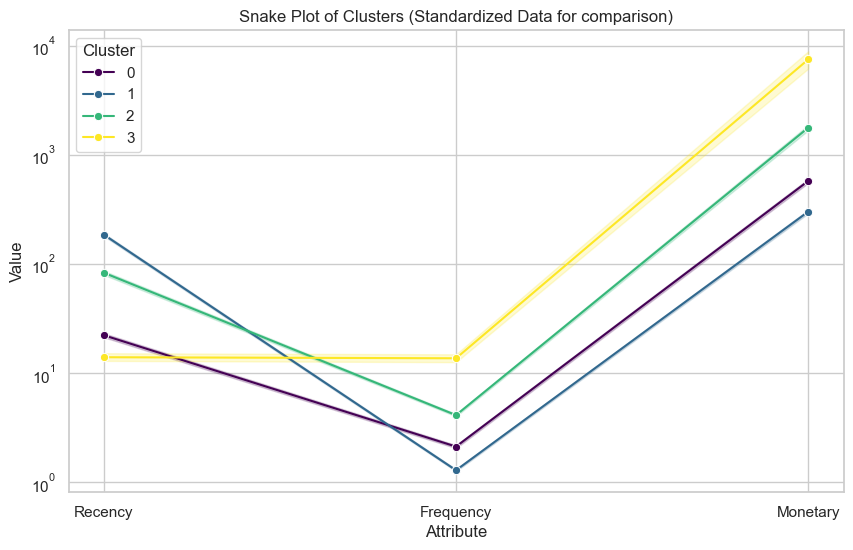

In [4]:
## 3. Final Model & Interpretation

# Based on the plots, let's select K=4 (Common for RFM: Gold, Silver, Bronze, Inactive)
optimal_k = 4 
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42)

# Fit model
# We assign the cluster labels back to our main RFM dataframe
rfm['Cluster'] = final_kmeans.fit_predict(rfm_scaled)

# --- CLUSTER ANALYSIS ---

# RESET INDEX so 'Customer ID' becomes a column again for counting
rfm_reset = rfm.reset_index()

# Calculate average RFM values for each cluster
cluster_summary = rfm_reset.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Customer ID': 'count' # Now 'Customer ID' exists as a column
}).rename(columns={'Customer ID': 'Count'}).sort_values(by='Monetary', ascending=False)

print("Cluster Summary (Means):")
display(cluster_summary.round(2))

# --- VISUALIZATION: SNAKE PLOT ---
# Melt data for visualization
# We use rfm_reset here because it has both Customer ID and Cluster as columns
rfm_melt = pd.melt(rfm_reset, id_vars=['Customer ID', 'Cluster'],
                   value_vars=['Recency', 'Frequency', 'Monetary'],
                   var_name='Attribute', value_name='Value')

plt.figure(figsize=(10, 6))
sns.lineplot(x='Attribute', y='Value', hue='Cluster', data=rfm_melt, palette='viridis', marker="o")
plt.title('Snake Plot of Clusters (Standardized Data for comparison)')
plt.yscale('log') # Log scale helps view Monetary vs Frequency differences
plt.show()

DBSCAN estimated clusters: 3
Noise points (Outliers): 80


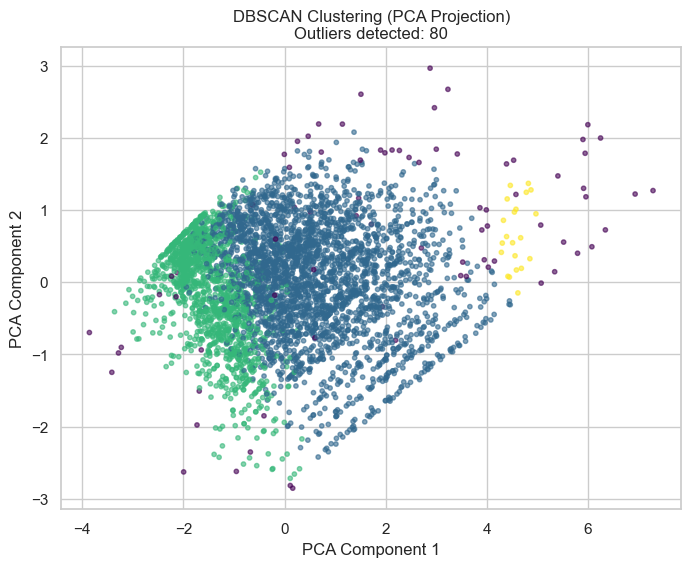


Comparison:
K-Means forces every customer into a group, which is useful for marketing segmentation coverage.
DBSCAN is excellent at finding 'Noise' (Outliers). In this context, noise points might be 
fraudulent transactions or extremely high-value 'Whales' that don't fit normal patterns.



In [5]:
## 4. Comparison Model: DBSCAN
# DBSCAN finds core samples of high density. Good for outliers.

# Fit DBSCAN
# eps=0.5 and min_samples=5 are starting points; usually require tuning
dbscan = DBSCAN(eps=0.5, min_samples=10)
clusters_db = dbscan.fit_predict(rfm_scaled)

# Check results
n_clusters = len(set(clusters_db)) - (1 if -1 in clusters_db else 0)
n_noise = list(clusters_db).count(-1)

print(f"DBSCAN estimated clusters: {n_clusters}")
print(f"Noise points (Outliers): {n_noise}")

# Visualizing DBSCAN via PCA (Dimensionality Reduction)
pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(rfm_pca[:, 0], rfm_pca[:, 1], c=clusters_db, cmap='viridis', s=10, alpha=0.6)
plt.title(f'DBSCAN Clustering (PCA Projection)\nOutliers detected: {n_noise}')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

print("""
Comparison:
K-Means forces every customer into a group, which is useful for marketing segmentation coverage.
DBSCAN is excellent at finding 'Noise' (Outliers). In this context, noise points might be 
fraudulent transactions or extremely high-value 'Whales' that don't fit normal patterns.
""")

## 5. Findings & Recommendations

### Customer Personas
Based on our K-Means analysis, we have identified 4 distinct customer segments:

1.  **The "Champions" (High Monetary, High Frequency, Low Recency):**
    * *Characteristics:* They bought recently, buy often, and spend the most.
    * *Strategy:* Reward loyalty. Offer early access to new products. No discounts needed.
2.  **The "Loyalists" (Moderate Monetary, High Frequency):**
    * *Characteristics:* Regular shoppers but spend less per basket than Champions.
    * *Strategy:* Upsell/Cross-sell to increase basket size.
3.  **The "At-Risk" (High Monetary, High Recency):**
    * *Characteristics:* Big spenders who haven't visited in a while.
    * *Strategy:* Aggressive win-back campaigns. Send personalized "We miss you" offers.
4.  **The "Hibernating" (Low Monetary, Low Frequency, High Recency):**
    * *Characteristics:* Low value, infrequent, long time since last visit.
    * *Strategy:* Low priority. Use automated, low-cost emails to try and reactivate.

### Conclusion
By shifting from mass marketing to this segmented approach, the business can allocate its budget more efficiently—spending high-cost retention dollars only on the "At-Risk" group while automating engagement for "Champions."